## File Descriptions
* **Data Exploration** – Exploratory analysis of the dataset.

* **Data Preprocessing** – Data cleaning and transformation for model readiness.

* **Modelling** – Experimentation with various machine learning models.

* **Alternative Approach** – Exploration of a different methodology to solve the problem.

* **Final Model** – Contains the final model used to generate leaderboard-level predictions.

## Objective
The goal is to build a machine learning model to predict Customer Lifetime Value (CLTV) using user and policy-related features. CLTV estimates the total revenue a customer is expected to generate throughout their relationship with the company.

## Key Insights from Data Exploration
* The dataset contained 26 exact duplicate records.

* Over 12,000 duplicate-like entries were found with differing CLTV values, potentially indicating external influences and affecting model learning.

* The CLTV distribution is highly left-skewed, making R-squared a less ideal evaluation metric.

* The majority of customers are from urban areas, have an income between 5L–10L, own multiple policies, and most commonly purchase Platinum A policies.

* Number of policies and residential area showed a strong impact on CLTV.

* There is a clear correlation between claim amount and CLTV.

## Data Preprocessing Summary
* Removed the 26 duplicate records.

* Applied feature engineering to enhance the usefulness of income and marital status.

* Scaled numerical features to avoid bias in training.

* Used one-hot encoding (via pd.get_dummies) for categorical variables.

* Dropped additional feature engineering efforts as they did not significantly improve model performance.

## Model Development
* Multiple models were evaluated for predictive accuracy.

* CatBoost and XGBRF showed superior performance compared to other models, with minimal differences between them.

* Hyperparameter tuning had limited effect on performance.

* Stacked models provided a slight boost in accuracy.

## Final Model Selection
* CatBoost was chosen for its balance of accuracy and interpretability.

* Stacked models were avoided to maintain transparency.

* Feature importance from CatBoost enhanced model explainability.

* Minimal preprocessing was required for CatBoost, and additional feature engineering did not offer significant gains.

## Suggestions for Improvement
* The presence of numerous duplicate entries with varying CLTV values suggests the influence of unobserved or missing variables. To enhance the model's predictive power, consider incorporating additional features such as:

    * Customer age

    * Employment type

    * Policy pricing

These variables could provide deeper insights into customer behavior and significantly improve the model's performance.

* Additionally, an alternative approach worth exploring is to categorize the continuous CLTV variable into defined ranges or segments (e.g., low, medium, high value customers). This classification-based strategy may improve model interpretability .

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#  load Data
df= pd.read_csv('train.csv',index_col=0)

## DATA EXPLORATION

In [3]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(4)

,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
id,,,,,,,,,,,
34376,Female,Rural,Bachelor,5L-10L,1,4,0,More than 1,A,Platinum,58764
67917,Female,Rural,Bachelor,5L-10L,1,4,0,More than 1,A,Platinum,58764
29854,Female,Rural,Bachelor,5L-10L,1,5,0,1,B,Platinum,33504
79914,Female,Rural,Bachelor,5L-10L,1,5,0,1,B,Platinum,33504


Given Data contains duplicated value

In [4]:
sum(df.duplicated())

26

There are 26 duplicate records in the data ,So we are dropping them

In [5]:
df= df.drop_duplicates()

In [6]:
y= df.cltv
X = df.drop('cltv',axis=1).copy()

In [7]:
sum(X.duplicated())

12714

In [8]:
X[X.duplicated(keep=False)].sort_values(by=list(X.columns)).head()

,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy
id,,,,,,,,,,
2401,Female,Rural,Bachelor,2L-5L,0,0,0,More than 1,B,Platinum
26752,Female,Rural,Bachelor,2L-5L,0,0,0,More than 1,B,Platinum
29120,Female,Rural,Bachelor,2L-5L,0,0,0,More than 1,B,Platinum
79488,Female,Rural,Bachelor,2L-5L,0,0,0,More than 1,B,Platinum
17464,Female,Rural,Bachelor,2L-5L,0,2,0,More than 1,A,Platinum


There are more than 12000 duplicated entry, with different target variable. This will introduce large errors in our model as it will affect ability of model to learn. It also indicate influence of outside variables

In [9]:
test= pd.read_csv('test.csv',index_col=0)
test[test.duplicated(keep=False)].sort_values(list(test.columns))

,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy
id,,,,,,,,,,
102094,Female,Rural,Bachelor,2L-5L,0,2,0,More than 1,A,Platinum
125691,Female,Rural,Bachelor,2L-5L,0,2,0,More than 1,A,Platinum
93182,Female,Rural,Bachelor,2L-5L,0,2,0,More than 1,A,Silver
142815,Female,Rural,Bachelor,2L-5L,0,2,0,More than 1,A,Silver
101583,Female,Rural,Bachelor,2L-5L,0,3,0,More than 1,A,Platinum
...,...,...,...,...,...,...,...,...,...,...
138709,Male,Urban,Others,5L-10L,1,7,0,1,A,Gold
110149,Male,Urban,Others,5L-10L,1,8,0,1,B,Platinum
125399,Male,Urban,Others,5L-10L,1,8,0,1,B,Platinum


There are duplicate data at the test data set as well 

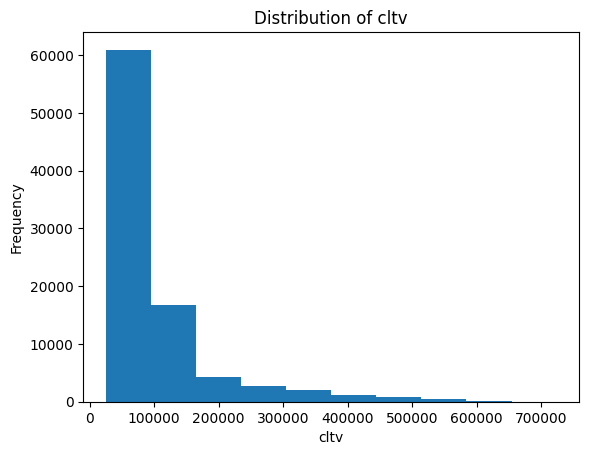

Mean:  97966.41375914778
Median:  66408.0
Standard Deviation:  90622.72757011713


In [10]:
# Understand the distribution of the target variable 'cltv'
plt.hist(y)
plt.xlabel('cltv')
plt.ylabel('Frequency')
plt.title('Distribution of cltv')
plt.show()
print("Mean: ", y.mean())
print("Median: ", y.median())
print("Standard Deviation: ", y.std())

Distribution of y is leftword skewed, as we are training 'r2' as accuracy it will negatively affect our model

In [11]:
# converting marital status into category for analysis

X.marital_status=X.marital_status.astype('object')
test.marital_status=test.marital_status.astype('object')

In [12]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89366 entries, 1 to 89392
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   gender          89366 non-null  object
 1   area            89366 non-null  object
 2   qualification   89366 non-null  object
 3   income          89366 non-null  object
 4   marital_status  89366 non-null  object
 5   vintage         89366 non-null  int64 
 6   claim_amount    89366 non-null  int64 
 7   num_policies    89366 non-null  object
 8   policy          89366 non-null  object
 9   type_of_policy  89366 non-null  object
dtypes: int64(2), object(8)
memory usage: 7.5+ MB


In [13]:
for column in df.select_dtypes('object').columns:
    print(df[column].value_counts(),'\n')

gender
Male      50484
Female    38882
Name: count, dtype: int64 

area
Urban    62450
Rural    26916
Name: count, dtype: int64 

qualification
High School    46233
Bachelor       39387
Others          3746
Name: count, dtype: int64 

income
5L-10L           52693
2L-5L            21158
More than 10L    13661
<=2L              1854
Name: count, dtype: int64 

num_policies
More than 1    60254
1              29112
Name: count, dtype: int64 

policy
A    56627
B    24626
C     8113
Name: count, dtype: int64 

type_of_policy
Platinum    47777
Silver      21005
Gold        20584
Name: count, dtype: int64 



The data demonstrates a higher proportion of individuals residing in urban areas, with an income between 5L-10L, holding multiple policies, and predominantly purchasing A policies of the Platinum type.

Does not contain any missing values

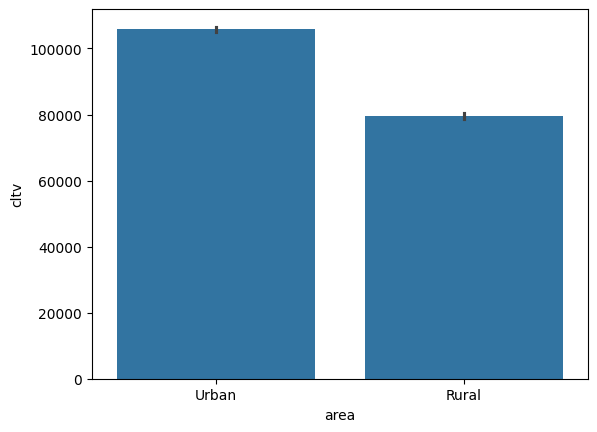

In [14]:
# Analyze the relationship between 'cltv' and other independent variables

sns.barplot(x='area', y='cltv', data=df)
plt.show()

Number of policies and area in which customer lives have huge impact on customer life time value

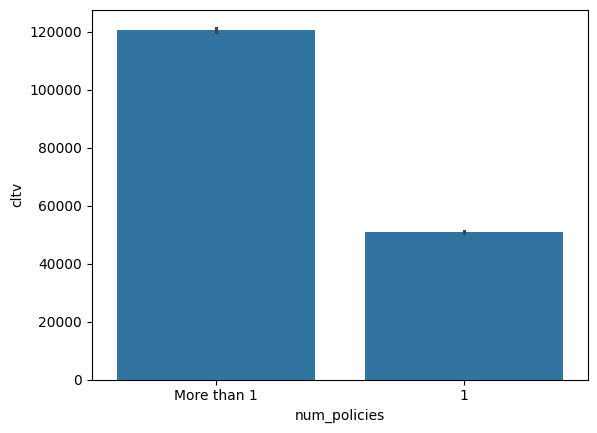

In [15]:
sns.barplot(x='num_policies', y='cltv', data=df)
plt.show()

Others are very small in number,so not much useful

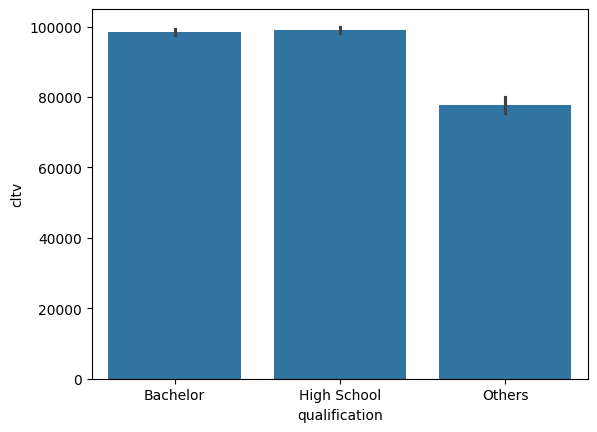

In [16]:
sns.barplot(x='qualification', y='cltv', data=df)
plt.show()

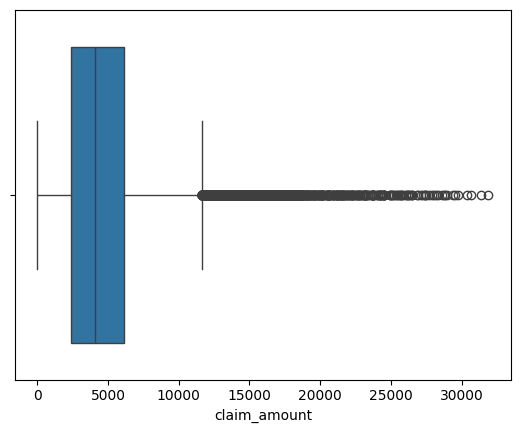

In [17]:
# Look for patterns in the data
sns.boxplot(x='claim_amount', data=df)
plt.show()

In [18]:
# Identify categorical columns (non-numeric)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Convert to numeric codes
for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes.astype(int)  # Explicitly convert to integer


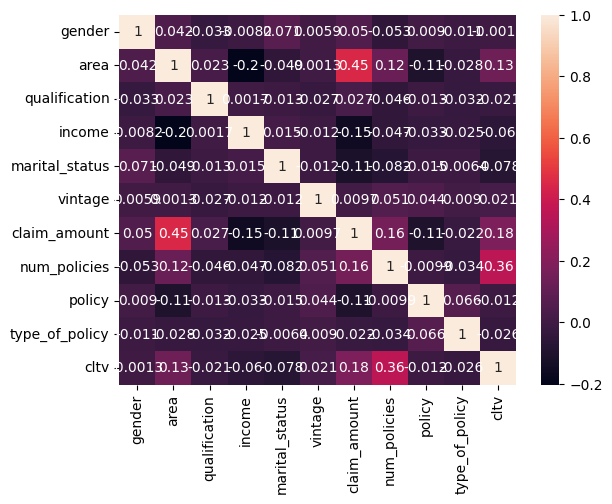

In [19]:
# Study the correlation between independent variables and 'cltv'
corr = df.corr()
sns.heatmap(corr, annot=True)
plt.show()

There is some correlation between claim amount and cltv

In [20]:
import itertools
import pandas as pd

# Select only categorical variables from the dataframe
categorical_vars = X.select_dtypes(include=['object', 'category'])

# Get all combinations of pairs of variables
combinations = list(itertools.combinations(categorical_vars.columns, 2))

# Iterate over all pairs of variables and create a cross-table
for var1, var2 in combinations:
    cross_table = pd.crosstab(categorical_vars[var1], categorical_vars[var2])
    print(cross_table,'\n')

area    Rural  Urban
gender              
Female  12573  26309
Male    14343  36141 

qualification  Bachelor  High School  Others
gender                                      
Female            16343        20870    1669
Male              23044        25363    2077 

income  2L-5L  5L-10L  <=2L  More than 10L
gender                                    
Female   9493   22210  1038           6141
Male    11665   30483   816           7520 

marital_status      0      1
gender                      
Female          18053  20829
Male            19889  30595 

num_policies      1  More than 1
gender                          
Female        11570        27312
Male          17542        32942 

policy      A      B     C
gender                    
Female  24801  10649  3432
Male    31826  13977  4681 

type_of_policy   Gold  Platinum  Silver
gender                                 
Female           8969     20436    9477
Male            11615     27341   11528 

qualification  Bachelor  High Scho

## DATA PREPROCESSING

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,RobustScaler

In [22]:
train_data= pd.read_csv('train.csv',index_col=0)
test_data= pd.read_csv('test.csv',index_col=0)

In [23]:
# Removing duplicates
train_data = train_data.drop_duplicates()

In [24]:
train_data.head()

,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
id,,,,,,,,,,,
1,Male,Urban,Bachelor,5L-10L,1,5,5790,More than 1,A,Platinum,64308
2,Male,Rural,High School,5L-10L,0,8,5080,More than 1,A,Platinum,515400
3,Male,Urban,Bachelor,5L-10L,1,8,2599,More than 1,A,Platinum,64212
4,Female,Rural,High School,5L-10L,0,7,0,More than 1,A,Platinum,97920
5,Male,Urban,High School,More than 10L,1,6,3508,More than 1,A,Gold,59736


In [25]:
test_data.head()

,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy
id,,,,,,,,,,
89393,Female,Rural,High School,5L-10L,0,6,2134,More than 1,B,Silver
89394,Female,Urban,High School,2L-5L,0,4,4102,More than 1,A,Platinum
89395,Male,Rural,High School,5L-10L,1,7,2925,More than 1,B,Gold
89396,Female,Rural,Bachelor,More than 10L,1,2,0,More than 1,B,Silver
89397,Female,Urban,High School,2L-5L,0,5,14059,More than 1,B,Silver


In [26]:
target = train_data.pop('cltv')

In [27]:
def purchasing_power(x):
    
    # ratio is chosen based on general understanding and is not a fixed number
    #purchasing power is different for rural and urban income
    
    ratio =1.3
    if x['income']=='0-2L':
        if x['area']=='Rural':
            return 2
        else:
            return 2/ratio
    if x['income']=='2L-5L':
        if x['area']=='Rural':
            return 5
        else:
            return 5/ratio
        
    if x['income']=='5L-10L':
        if x['area']=='Rural':
            return 10
        else:
            return 10/ratio
        
    if x['income']=='More than 10L':
        if x['area']=='Rural':
            return 15
        else:
            return 15/ratio
        

In [28]:
def feature_engineering(df_received):
    
    df_transformed= df_received.copy()
    
    # changing only '<=2L' in income as it is not suitable for data column name
    map_income= {'5L-10L':'5L-10L', '2L-5L':'2L-5L', 'More than 10L':'More than 10L', '<=2L':'0-2L'}
    df_transformed['income']= df_transformed['income'].map(map_income)
    
    #purchasing power is different for rural and urban income
    df_transformed['purchasing_power']= df_transformed.apply(purchasing_power,axis=1)
    
    # changing marital status from numerical to categorical- useful for our scaling done later on
    map_marital= {1:'married',0:'not married'}
    df_transformed['marital_status']= df_transformed['marital_status'].map(map_marital)
    
    # created a new column that  tells about whether a person has made claim or not
    df_transformed['is_claimed']= df_transformed.apply(lambda x: 'yes' if x['claim_amount']>0 else 'no',axis=1)
    
    # earning to company has been created based on number of policies and how many year ago he bought his first policy
    df_transformed['earning_to_company']=df_transformed.apply(lambda x: x['vintage']*2.5 \
                                                   if x['num_policies']=='More than 1' else x['vintage'],axis=1)
    
    # claim amount per year can help us reduce effect of the number of years a person has been a member of policy
    df_transformed['claim_amount_per_year']=df_transformed['claim_amount']/(df_transformed.vintage +1)
    
    # it is done to help model differentiate between new cutomer and past customers
    df_transformed['new_customer'] = df_transformed.apply(lambda x:'yes' if x['vintage']<1 else 'no',axis=1)
    
    #claim per policy can reduce effect of number of policy on claims and is better measure
    df_transformed['claim_per_policy'] = df_transformed.apply(lambda x:x['claim_amount']/2 if x['num_policies']=='More than 1' \
                                                              else x['claim_amount'],axis=1)
    
    # to measure influence of corona on insurance habits
    df_transformed['during_corona'] = df_transformed.apply(lambda x:'yes' if x['vintage'] <=3 and x['vintage']>=1 else 'no',axis=1)

   

    return df_transformed
    

In [29]:
train_data = feature_engineering(train_data)
test_data = feature_engineering(test_data)

In [30]:
train_data.head()

,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,purchasing_power,is_claimed,earning_to_company,claim_amount_per_year,new_customer,claim_per_policy,during_corona
id,,,,,,,,,,,,,,,,,
1,Male,Urban,Bachelor,5L-10L,married,5,5790,More than 1,A,Platinum,7.692308,yes,12.5,965.000000,no,2895.0,no
2,Male,Rural,High School,5L-10L,not married,8,5080,More than 1,A,Platinum,10.000000,yes,20.0,564.444444,no,2540.0,no
3,Male,Urban,Bachelor,5L-10L,married,8,2599,More than 1,A,Platinum,7.692308,yes,20.0,288.777778,no,1299.5,no
4,Female,Rural,High School,5L-10L,not married,7,0,More than 1,A,Platinum,10.000000,no,17.5,0.000000,no,0.0,no
5,Male,Urban,High School,More than 10L,married,6,3508,More than 1,A,Gold,11.538462,yes,15.0,501.142857,no,1754.0,no


In [31]:
test_data.head()

,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,purchasing_power,is_claimed,earning_to_company,claim_amount_per_year,new_customer,claim_per_policy,during_corona
id,,,,,,,,,,,,,,,,,
89393,Female,Rural,High School,5L-10L,not married,6,2134,More than 1,B,Silver,10.000000,yes,15.0,304.857143,no,1067.0,no
89394,Female,Urban,High School,2L-5L,not married,4,4102,More than 1,A,Platinum,3.846154,yes,10.0,820.400000,no,2051.0,no
89395,Male,Rural,High School,5L-10L,married,7,2925,More than 1,B,Gold,10.000000,yes,17.5,365.625000,no,1462.5,no
89396,Female,Rural,Bachelor,More than 10L,married,2,0,More than 1,B,Silver,15.000000,no,5.0,0.000000,no,0.0,yes
89397,Female,Urban,High School,2L-5L,not married,5,14059,More than 1,B,Silver,3.846154,yes,12.5,2343.166667,no,7029.5,no


In [32]:
# scaling numerical variables
numerical_column= train_data.select_dtypes('number').columns

# robust scaling was used as our data do not have normal distribution
sc = RobustScaler()

train_data[numerical_column]= sc.fit_transform(train_data[numerical_column])

test_data[numerical_column]= sc.transform(test_data[numerical_column])

In [33]:
train_data.head()

,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,purchasing_power,is_claimed,earning_to_company,claim_amount_per_year,new_customer,claim_per_policy,during_corona
id,,,,,,,,,,,,,,,,,
1,Male,Urban,Bachelor,5L-10L,married,0.000000,0.461382,More than 1,A,Platinum,0.000000,yes,0.50,0.240838,no,0.149203,no
2,Male,Rural,High School,5L-10L,not married,1.000000,0.268800,More than 1,A,Platinum,0.461538,yes,1.25,-0.197966,no,0.011626,no
3,Male,Urban,Bachelor,5L-10L,married,1.000000,-0.404150,More than 1,A,Platinum,0.000000,yes,1.25,-0.499957,no,-0.469118,no
4,Female,Rural,High School,5L-10L,not married,0.666667,-1.109107,More than 1,A,Platinum,0.461538,no,1.00,-0.816310,no,-0.972727,no
5,Male,Urban,High School,More than 10L,married,0.333333,-0.157591,More than 1,A,Gold,0.769231,yes,0.75,-0.267313,no,-0.292981,no


In [34]:
test_data.head()

,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,purchasing_power,is_claimed,earning_to_company,claim_amount_per_year,new_customer,claim_per_policy,during_corona
id,,,,,,,,,,,,,,,,,
89393,Female,Rural,High School,5L-10L,not married,0.333333,-0.530277,More than 1,B,Silver,0.461538,yes,0.75,-0.482342,no,-0.559221,no
89394,Female,Urban,High School,2L-5L,not married,-0.333333,0.003526,More than 1,A,Platinum,-0.769231,yes,0.25,0.082430,no,-0.177881,no
89395,Male,Rural,High School,5L-10L,married,0.666667,-0.315725,More than 1,B,Gold,0.461538,yes,1.00,-0.415771,no,-0.405949,no
89396,Female,Rural,Bachelor,More than 10L,married,-1.000000,-1.109107,More than 1,B,Silver,1.461538,no,-0.25,-0.816310,no,-0.972727,yes
89397,Female,Urban,High School,2L-5L,not married,0.000000,2.704279,More than 1,B,Silver,-0.769231,yes,0.50,1.750606,no,1.751490,no


In [35]:
# Encoding our categorical variable by use of pandas dummy function
# 'drop first' is true as first column doesn't provide any extra information and can be derived from remaining column

train_data= pd.get_dummies(train_data,drop_first=True)
test_data= pd.get_dummies(test_data,drop_first=True)

In [36]:
# Adding 'cltv' back
train_data['cltv']= target

In [37]:
train_data.head()

,vintage,claim_amount,purchasing_power,earning_to_company,claim_amount_per_year,claim_per_policy,gender_Male,area_Urban,qualification_High School,qualification_Others,...,marital_status_not married,num_policies_More than 1,policy_B,policy_C,type_of_policy_Platinum,type_of_policy_Silver,is_claimed_yes,new_customer_yes,during_corona_yes,cltv
id,,,,,,,,,,,,,,,,,,,,,
1,0.000000,0.461382,0.000000,0.50,0.240838,0.149203,True,True,False,False,...,False,True,False,False,True,False,True,False,False,64308
2,1.000000,0.268800,0.461538,1.25,-0.197966,0.011626,True,False,True,False,...,True,True,False,False,True,False,True,False,False,515400
3,1.000000,-0.404150,0.000000,1.25,-0.499957,-0.469118,True,True,False,False,...,False,True,False,False,True,False,True,False,False,64212
4,0.666667,-1.109107,0.461538,1.00,-0.816310,-0.972727,False,False,True,False,...,True,True,False,False,True,False,False,False,False,97920
5,0.333333,-0.157591,0.769231,0.75,-0.267313,-0.292981,True,True,True,False,...,False,True,False,False,False,False,True,False,False,59736


In [38]:
test_data.head()

,vintage,claim_amount,purchasing_power,earning_to_company,claim_amount_per_year,claim_per_policy,gender_Male,area_Urban,qualification_High School,qualification_Others,...,income_More than 10L,marital_status_not married,num_policies_More than 1,policy_B,policy_C,type_of_policy_Platinum,type_of_policy_Silver,is_claimed_yes,new_customer_yes,during_corona_yes
id,,,,,,,,,,,,,,,,,,,,,
89393,0.333333,-0.530277,0.461538,0.75,-0.482342,-0.559221,False,False,True,False,...,False,True,True,True,False,False,True,True,False,False
89394,-0.333333,0.003526,-0.769231,0.25,0.082430,-0.177881,False,True,True,False,...,False,True,True,False,False,True,False,True,False,False
89395,0.666667,-0.315725,0.461538,1.00,-0.415771,-0.405949,True,False,True,False,...,False,False,True,True,False,False,False,True,False,False
89396,-1.000000,-1.109107,1.461538,-0.25,-0.816310,-0.972727,False,False,False,False,...,True,False,True,True,False,False,True,False,False,True
89397,0.000000,2.704279,-0.769231,0.50,1.750606,1.751490,False,True,True,False,...,False,True,True,True,False,False,True,True,False,False


We have got a nice preprocessed data, let's save it for future use

In [39]:
train_data.to_csv('processed_train.csv')
test_data.to_csv('processed_test.csv')

In [40]:
pd.read_csv('processed_train.csv',index_col=0).head()

,vintage,claim_amount,purchasing_power,earning_to_company,claim_amount_per_year,claim_per_policy,gender_Male,area_Urban,qualification_High School,qualification_Others,...,marital_status_not married,num_policies_More than 1,policy_B,policy_C,type_of_policy_Platinum,type_of_policy_Silver,is_claimed_yes,new_customer_yes,during_corona_yes,cltv
id,,,,,,,,,,,,,,,,,,,,,
1,0.000000,0.461382,0.000000,0.50,0.240838,0.149203,True,True,False,False,...,False,True,False,False,True,False,True,False,False,64308
2,1.000000,0.268800,0.461538,1.25,-0.197966,0.011626,True,False,True,False,...,True,True,False,False,True,False,True,False,False,515400
3,1.000000,-0.404150,0.000000,1.25,-0.499957,-0.469118,True,True,False,False,...,False,True,False,False,True,False,True,False,False,64212
4,0.666667,-1.109107,0.461538,1.00,-0.816310,-0.972727,False,False,True,False,...,True,True,False,False,True,False,False,False,False,97920
5,0.333333,-0.157591,0.769231,0.75,-0.267313,-0.292981,True,True,True,False,...,False,True,False,False,False,False,True,False,False,59736


## MODELLING

In [41]:
# importing required libraries

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from sklearn.ensemble import StackingRegressor

In [42]:
train_data= pd.read_csv('processed_train.csv',index_col=0)

In [43]:
y = train_data.pop('cltv')
X = train_data.copy()

In [44]:
# Split the data into 70% training, 15% evaluation, and 15% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
print(f'X_train shape : {X_train.shape}')
print(f'X_test shape : {X_test.shape}')

X_train shape : (71492, 22)
X_test shape : (17874, 22)


## 1. Linear Model 

A linear model (like Linear Regression) predicts a target variable by finding a linear relationship between input features and the output.
It’s used as a baseline because it's simple, interpretable, and helps identify whether complex models are truly adding value.

In [46]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train,y_train)
print(f'linear model r2 score is {linear_model.score(X_test,y_test)}')

linear model r2 score is 0.15841545929133272


In [47]:
# saving results
test_data = pd.read_csv('processed_test.csv',index_col=0)
prediction1= linear_model.predict(test_data)

submission = pd.DataFrame({'id':test_data.index,'cltv':prediction1})

submission.to_csv('submission_linear_model.csv',index=False)

## 2. CatBoost Model

CatBoost is a gradient boosting algorithm by Yandex that natively handles categorical features with minimal preprocessing.

In [48]:
# initialize the model
cat_model = CatBoostRegressor(iterations=1200, learning_rate=0.01, depth=6,loss_function='RMSE')

# fit the model on the training data
cat_model.fit(X_train, y_train, eval_set=(X_test, y_test), logging_level='Silent',plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [49]:
# make predictions on the test set
y_pred_cat = cat_model.predict(X_test)
print(f'r2 score of catboost model {r2_score(y_test, y_pred_cat)}')

r2 score of catboost model 0.16381235169549657


High score is due to we test dataset as evaluation parameter above

In [50]:
# seeing important features
feature_importance= pd.DataFrame({'feature':X_train.columns,'importance':cat_model.feature_importances_})
feature_importance.sort_values(by='importance',ascending=False)[:10].reset_index(drop=['id'])

,feature,importance
0,num_policies_More than 1,72.296026
1,claim_amount,4.034353
2,claim_per_policy,3.710989
3,purchasing_power,2.296248
4,marital_status_not married,2.288515
5,policy_B,2.211260
6,area_Urban,2.093226
7,claim_amount_per_year,2.032714
8,policy_C,1.805925
9,earning_to_company,1.666762


In [51]:
# saving results
test_data = pd.read_csv('processed_test.csv',index_col=0)

prediction2= cat_model.predict(test_data)

submission = pd.DataFrame({'id':test_data.index,'cltv':prediction2})

submission.to_csv('submission_cat_model.csv',index=False)

This resulted in test_data r2 score = 0.1590

## 3. XGBRF Regressor
XGBRFRegressor is a variant of XGBoost that uses random forests instead of gradient boosting, combining XGBoost's regularization with bagging.
It’s useful when you prefer random forest-style learning with XGBoost’s optimization features like column subsampling and early stopping.

In [52]:
model_xgbrf_regressor = xgb.XGBRFRegressor()
model_xgbrf_regressor.fit(X_train,y_train)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, objective='reg:squarederror',
               random_state=None, ...)

In [53]:
# make predictions on the test set
y_pred_xgbrf_regressor = model_xgbrf_regressor.predict(X_test)

# evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgbrf_regressor))
print("RMSE: ", rmse)
from sklearn.metrics import r2_score
print(r2_score(y_test, y_pred_xgbrf_regressor))

RMSE:  82943.18826763293
0.16009777784347534


In [54]:
# saving results
test_data = pd.read_csv('processed_test.csv',index_col=0)
prediction3= model_xgbrf_regressor.predict(test_data)

submission = pd.DataFrame({'id':test_data.index,'cltv':prediction3})

submission.to_csv('submission_xgbrf.csv',index=False)

accuracy on test data 0.155797714687998

## 4. Stacking of different models 

Stacking combines multiple diverse models (e.g., CatBoost, XGBoost, Linear Regression) to capture different patterns and reduce individual model biases.
It was tested to see if blending strengths of various algorithms could improve overall accuracy and handle complex relationships better than any single model.

In [55]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

estimators = [('lr', LinearRegression()), 
              ('catboost', CatBoostRegressor(iterations=1000, learning_rate=0.01, depth=6,loss_function='RMSE')),
              ('xgbrf',xgb.XGBRFRegressor())]

stacked_model = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())
stacked_model.fit(X_train, y_train)

0:	learn: 90515.3991451	total: 17.7ms	remaining: 17.7s
1:	learn: 90378.4341637	total: 35.4ms	remaining: 17.6s
2:	learn: 90245.8896688	total: 55.5ms	remaining: 18.5s
3:	learn: 90116.0855674	total: 71.9ms	remaining: 17.9s
4:	learn: 89987.3185061	total: 88.6ms	remaining: 17.6s
5:	learn: 89863.3681413	total: 105ms	remaining: 17.4s
6:	learn: 89740.1202862	total: 121ms	remaining: 17.2s
7:	learn: 89620.2310250	total: 139ms	remaining: 17.2s
8:	learn: 89501.0400317	total: 155ms	remaining: 17.1s
9:	learn: 89383.9788390	total: 171ms	remaining: 16.9s
10:	learn: 89270.9805791	total: 186ms	remaining: 16.7s
11:	learn: 89158.2671918	total: 202ms	remaining: 16.6s
12:	learn: 89047.2064222	total: 217ms	remaining: 16.5s
13:	learn: 88941.4188821	total: 238ms	remaining: 16.8s
14:	learn: 88835.5993145	total: 263ms	remaining: 17.3s
15:	learn: 88732.0769223	total: 282ms	remaining: 17.4s
16:	learn: 88630.2054980	total: 298ms	remaining: 17.3s
17:	learn: 88529.1709223	total: 314ms	remaining: 17.1s
18:	learn: 8843

StackingRegressor(estimators=[('lr', LinearRegression()),
                              ('catboost',
                               <catboost.core.CatBoostRegressor object at 0x00000200B1B5AF90>),
                              ('xgbrf',
                               XGBRFRegressor(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None,
                                              feature_...
                                              interaction_constraints=None,
                                              max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None,
                                              objective='reg:squarederror',
                                              random_state=None, ...))],
                  final_estimator=LinearRegression())

In [56]:
# make predictions on the test set
stacked_pred = stacked_model.predict(X_test)

# evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, stacked_pred))
print("RMSE: ", rmse)
from sklearn.metrics import r2_score
print(r2_score(y_test, stacked_pred))

RMSE:  82779.21861196695
0.1634152311039786


In [57]:
# saving results
test_data = pd.read_csv('processed_test.csv',index_col=0)
prediction4= stacked_model.predict(test_data)

submission = pd.DataFrame({'id':test_data.index,'cltv':prediction4})

submission.to_csv('submission_stacked.csv',index=False)

## Comparison Between Models

In [58]:
pd.DataFrame({'cat_model':y_pred_cat.astype('int'), \
             'xgbrf_regressor':y_pred_xgbrf_regressor.astype('int'),\
              'linear':linear_model.predict(X_test).astype('int'),\
              'stacked_model':stacked_pred.astype('int'),'Actual':y_test},index=y_test.index)

,cat_model,xgbrf_regressor,linear,stacked_model,Actual
id,,,,,
48088,129005,131344,124537,129281,330168
86917,127290,130827,126807,128145,264228
59874,126762,123221,125642,126163,57720
59081,115010,112131,118581,114939,103332
62158,104359,108161,109714,105600,63948
...,...,...,...,...,...
54036,135500,132572,134735,134934,59256
5869,47909,48264,42726,47210,62808
7001,93649,96320,96611,94388,65304


Our prediction is lot closer for lower range 'cltv' score than for large value

## Alternative Approach

In [59]:
# importing required libraries

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [60]:
train_data= pd.read_csv('processed_train.csv',index_col=0)

<Axes: ylabel='Frequency'>

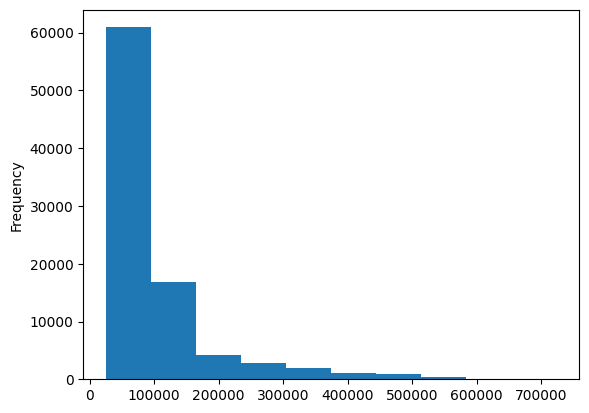

In [61]:
train_data.cltv.plot.hist()

In [62]:
y= train_data.pop('cltv')
X = train_data.copy()

In [63]:
# Create a function to bin the data

def equal_frequency_binning(data, n_bins):
    
    # Determine the bin edges by using qcut() function
    binned_data,bins = pd.qcut(data, n_bins,labels=False, retbins=True)
    return binned_data,bins


n_bins = 4
binned_y,ranges = equal_frequency_binning(y, n_bins)

In [64]:
category_range = pd.DataFrame({'category':np.unique(binned_y), 'range': ['24828-52851','52851-66408',\
                                                       '66408-103452','103452-724068']}).set_index('category')

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, binned_y, test_size=0.3, random_state=42)

In [66]:
model = XGBClassifier()
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [67]:
model.score(X_test,y_test)

0.46866840731070497

In [68]:
data= pd.DataFrame({'predict': model.predict(X_test),'actual':y_test})

In [69]:
prediction= model.predict_proba(X_test)

In [70]:
print(category_range)

                  range
category               
0           24828-52851
1           52851-66408
2          66408-103452
3         103452-724068


Here Red color shows actual class of data

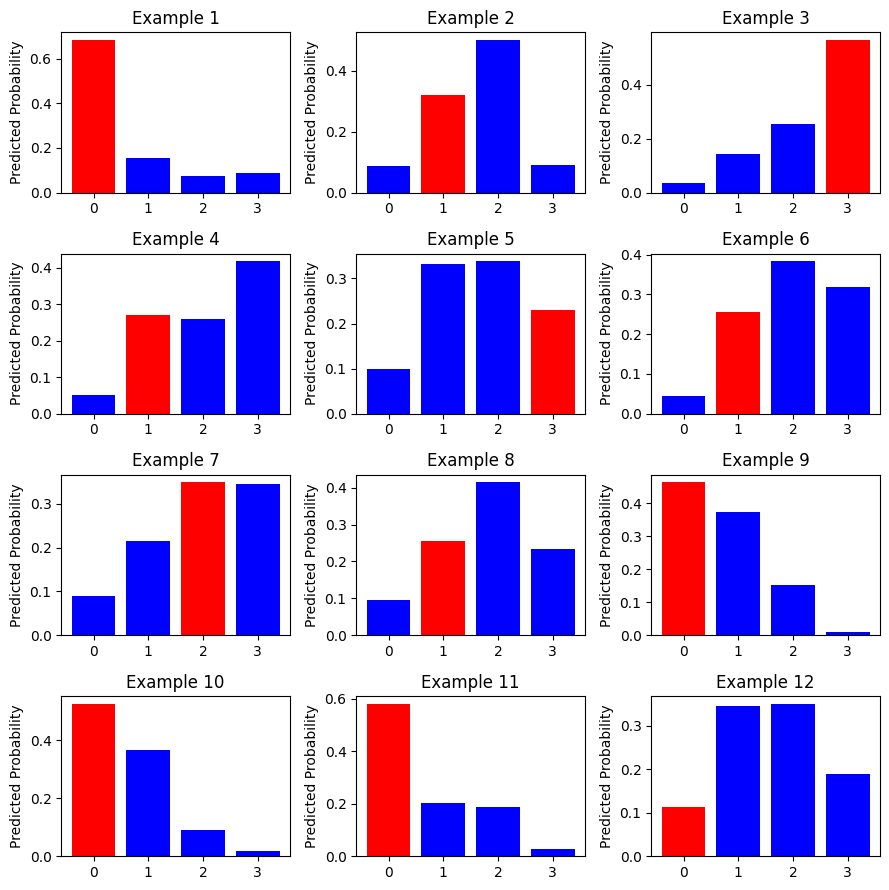

In [71]:
import matplotlib.pyplot as plt

# Create a 3x3 figure
fig, axs = plt.subplots(4, 3, figsize=(9, 9))

# Flatten the axes array so that we can easily access the subplots
axs = axs.ravel()

# Set the class labels
class_labels = [0, 1, 2, 3]

color_codes = ['blue', 'blue', 'blue', 'blue']

# Iterate over the subplots
for i, ax in enumerate(axs):
    # Get the data for the current subplot
    data = prediction[i+6]
    # Plot the bar graph
    color_codes = ['blue', 'blue', 'blue', 'blue']
    color_codes[y_test.values[i+6]]='red'
    
    ax.bar(class_labels, data, color=color_codes)
    # Set the title of the subplot
    ax.set_ylabel('Predicted Probability')
    ax.set_title('Example ' + str(i+1))

# Tighten the layout
plt.tight_layout()
# Show the plot
plt.show()


## Final Model

In [72]:
# importing required libraries

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from sklearn.metrics import r2_score

In [73]:
train_data= pd.read_csv('train.csv',index_col=0)
test_data= pd.read_csv('test.csv',index_col=0)

In [74]:
train_data.loc[train_data.income =='<=2L','income']= 'less than 2L'
test_data.loc[test_data.income =='<=2L','income']= 'less than 2L'

In [75]:
train_data.head(5)

,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
id,,,,,,,,,,,
1,Male,Urban,Bachelor,5L-10L,1,5,5790,More than 1,A,Platinum,64308
2,Male,Rural,High School,5L-10L,0,8,5080,More than 1,A,Platinum,515400
3,Male,Urban,Bachelor,5L-10L,1,8,2599,More than 1,A,Platinum,64212
4,Female,Rural,High School,5L-10L,0,7,0,More than 1,A,Platinum,97920
5,Male,Urban,High School,More than 10L,1,6,3508,More than 1,A,Gold,59736


In [76]:
train_data.marital_status= train_data.marital_status.astype('str')
test_data.marital_status= test_data.marital_status.astype('str')


In [77]:
# Removing duplicates
train_data = train_data.drop_duplicates()

In [78]:
y = train_data.pop('cltv')

In [79]:
categorical_columns= train_data.select_dtypes('object').columns

In [80]:
X_train, X_test, y_train, y_test = train_test_split(train_data, y, test_size=0.25, random_state=22)

In [81]:
from catboost import CatBoostRegressor
import numpy as np


# initialize the model
cat_model = CatBoostRegressor(iterations=1400, learning_rate=0.01, depth=5,\
                          loss_function='RMSE', cat_features=list(categorical_columns))

# fit the model on the training data
cat_model.fit(X_train, y_train, eval_set=(X_test, y_test), logging_level='Silent',plot=True)

# make predictions on the test set
y_pred = cat_model.predict(X_test)

# evaluate the model

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE: ", rmse)

r2_score(y_test, y_pred)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

RMSE:  82213.62074182871


0.1653480364856783

In [82]:
# seeing important features
feature_importance= pd.DataFrame({'feature':X_train.columns,'importance':cat_model.feature_importances_})
feature_importance.sort_values(by='importance',ascending=False)[:10].reset_index(drop=['id'])

,feature,importance
0,num_policies,80.850248
1,claim_amount,7.883702
2,policy,3.348487
3,area,3.186376
4,marital_status,1.313141
5,income,1.249338
6,qualification,0.767325
7,gender,0.570694
8,type_of_policy,0.476525
9,vintage,0.354164


Num of policies and Claim amount as major factor in prediction was also predicted during data exploration.

In [83]:
prediction= cat_model.predict(test_data)

submission = pd.DataFrame({'id':test_data.index,'cltv':prediction})

submission.to_csv('Parthiv_Das_B4_final_Solution_File.csv',index=False)